# Environment Cache Redirect
Redirect background library caching directories to optimize system storage space allocation.

In [37]:
import os
from pathlib import Path

cache_dir = Path(r"D:\ANN_Project_Cache")
cache_dir.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(cache_dir / "huggingface")
os.environ["TORCH_HOME"] = str(cache_dir / "torch")
os.environ["TEMP"] = str(cache_dir / "temp")
os.environ["TMP"] = str(cache_dir / "temp")

print("All background caches successfully rerouted to D drive.")

All background caches successfully rerouted to D drive.


# Project Setup & Paths
Configure root folders, workspace directories, and verify input/output dependencies on the system environment.

In [38]:
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd
from tqdm import tqdm
from pathlib import Path
import os
import random
import torch

DATA_ROOT   = Path(r"D:\Dataset")                              
MANUAL_PATH = Path(r"D:\Dataset\ami_public_manual_1.6.2")      
OUTPUT_ROOT = Path(r"D:\ANN\ANN_Project\working\outputs\processed_data")
SAVE_DIR    = Path(r"D:\ANN\ANN_Project\working\outputs\saved")

for d in [OUTPUT_ROOT, SAVE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Paths configured.")
print("DATA_ROOT   :", DATA_ROOT)
print("MANUAL_PATH :", MANUAL_PATH)
print("OUTPUT_ROOT :", OUTPUT_ROOT)
print("SAVE_DIR    :", SAVE_DIR)

Paths configured.
DATA_ROOT   : D:\Dataset
MANUAL_PATH : D:\Dataset\ami_public_manual_1.6.2
OUTPUT_ROOT : D:\ANN\ANN_Project\working\outputs\processed_data
SAVE_DIR    : D:\ANN\ANN_Project\working\outputs\saved


# Meetings Retrieval & Splitting
Isolate meeting audio folder items from the AMI Meeting Corpus and parse them into discrete training subsets.

In [39]:
NUM_MEETINGS = 50   
RANDOM_SEED  = 42
random.seed(RANDOM_SEED)

all_meetings = sorted(
    [audio_dir.parent for audio_dir in DATA_ROOT.glob('*/audio') if audio_dir.is_dir()],
    key=lambda f: f.name
)

n = len(all_meetings) if NUM_MEETINGS is None or NUM_MEETINGS >= len(all_meetings) else NUM_MEETINGS
meetings = random.sample(all_meetings, n)

val_ratio    = 0.2
val_size     = max(2, int(len(meetings) * val_ratio))
val_meetings   = meetings[:val_size]
train_meetings = meetings[val_size:]

print(f'Total meetings found     : {len(all_meetings)}')
print(f'Meetings selected        : {len(meetings)}')
print(f'Train: {len(train_meetings)} | Val: {len(val_meetings)}')

Total meetings found     : 171
Meetings selected        : 50
Train: 40 | Val: 10


# Audio Preprocessing & Sliding Windows
Define sliding window mechanics, compute localized voice frame boundaries, and set noise and silence suppression constants.

In [40]:
def load_audio(meeting_path, target_sr=16000):
    audio_dir = meeting_path / "audio"
    if not audio_dir.exists(): return None, None, None
    wav_files = list(audio_dir.glob("*.wav"))
    if not wav_files: return None, None, None

    tracks = {}
    for f in wav_files:
        for channel in range(5):
            if f"Headset-{channel}" in f.name:
                audio, sr = librosa.load(f, sr=target_sr, mono=True)
                tracks[f"Headset-{channel}"] = audio
                break
    if not tracks: return None, None, None

    min_len = min(len(a) for a in tracks.values())
    tracks  = {s: a[:min_len] for s, a in tracks.items()}
    mixed = np.sum(list(tracks.values()), axis=0)
    mixed = mixed / (np.max(np.abs(mixed)) + 1e-8)
    return mixed, tracks, target_sr

WINDOW_SEC = 30.0
HOP_SEC = 15.0
OVERLAP_SEC = WINDOW_SEC - HOP_SEC

def sliding_windows(audio, sr, window_sec=WINDOW_SEC, hop_sec=HOP_SEC):
    window_size = int(window_sec * sr)
    hop_size = int(hop_sec * sr)
    windows = []
    n = len(audio)
    if n == 0: return windows

    if n < window_size:
        padded = np.pad(audio, (0, window_size - n), mode='constant')
        windows.append({"start_time": 0.0, "end_time": n / sr, "audio": padded, "is_padded": True})
        return windows

    for start in range(0, n - window_size + 1, hop_size):
        end = start + window_size
        windows.append({"start_time": start / sr, "end_time": end / sr, "audio": audio[start:end], "is_padded": False})

    last_end_sample = int(windows[-1]["end_time"] * sr)
    if last_end_sample < n:
        start = n - window_size
        if start > int(windows[-1]["start_time"] * sr):
            windows.append({"start_time": start / sr, "end_time": n / sr, "audio": audio[start:n], "is_padded": False})
    return windows

def compute_rms(audio):
    return np.sqrt(np.mean(audio ** 2))

RMS_SILENCE_THRESHOLD = 0.00061

### Plot: Audio Waveform and Silence Thresholding
Visualize an example conversation sequence along with the calibrated root-mean-square amplitude limits for validation verification.

d:\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


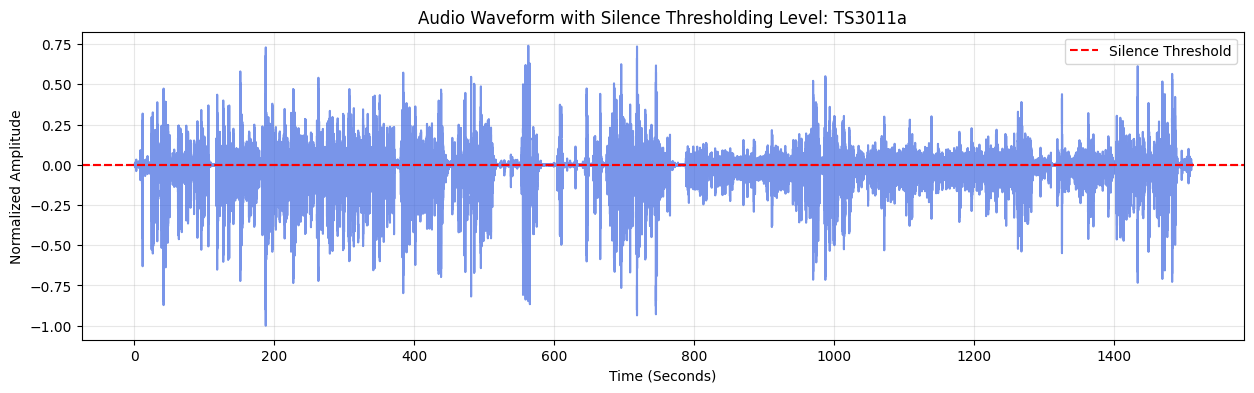

In [41]:
if len(meetings) > 0:
    example_meeting = meetings[0]
    mixed_audio, _, sr = load_audio(example_meeting)
    if mixed_audio is not None:
        plt.figure(figsize=(15, 4))
        time_axis = np.linspace(0, len(mixed_audio)/sr, len(mixed_audio))
        plt.plot(time_axis, mixed_audio, color='royalblue', alpha=0.7)
        plt.axhline(y=RMS_SILENCE_THRESHOLD, color='r', linestyle='--', label='Silence Threshold')
        plt.axhline(y=-RMS_SILENCE_THRESHOLD, color='r', linestyle='--')
        plt.title(f"Audio Waveform with Silence Thresholding Level: {example_meeting.name}")
        plt.xlabel("Time (Seconds)")
        plt.ylabel("Normalized Amplitude")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

# Save Preprocessed Windows
Segment continuous waveforms into sequential numpy structures and write corresponding index rows to file metadata charts.

In [42]:
audio_dir = OUTPUT_ROOT / f'windows_audio_{int(WINDOW_SEC)}s_{int(HOP_SEC)}s_hop'
audio_dir.mkdir(exist_ok=True)
rows = []

for meeting in tqdm(meetings):
    mixed, tracks, sr = load_audio(meeting)
    if mixed is None: continue

    windows = sliding_windows(mixed, sr, window_sec=WINDOW_SEC, hop_sec=HOP_SEC)
    for i, w in enumerate(windows):
        chunk = w['audio']
        rms = compute_rms(chunk)
        file_name = f"{meeting.name}_w{i}_{int(WINDOW_SEC)}s.npy"
        file_path = audio_dir / file_name
        np.save(file_path, chunk)

        rows.append({
            'meeting': meeting.name, 'window_idx': i,
            'start_time': w['start_time'], 'end_time': w['end_time'],
            'rms': rms, 'is_silent': rms < RMS_SILENCE_THRESHOLD,
            'audio_path': str(file_path)
        })

df_audio = pd.DataFrame(rows)
df_audio.to_csv(OUTPUT_ROOT / 'windows_metadata.csv', index=False)

100%|██████████| 50/50 [04:45<00:00,  5.71s/it]


# Speaker Label Assignment (XML Parsing)
Cross-reference temporal windows against manual ground truth transcript files to extract the dominant active talker identity label.

In [43]:
import xml.etree.ElementTree as ET
from sklearn.preprocessing import LabelEncoder

segments_dir = next(p for p in MANUAL_PATH.rglob('segments') if p.is_dir())
seg_files = sorted(segments_dir.glob('*.xml'), key=lambda x: x.name)
selected_meeting_names = {m.name for m in meetings}
matched = [f for f in seg_files if f.name.split('.')[0] in selected_meeting_names]

def parse_segments(xml_path):
    tree = ET.parse(xml_path)
    segments = [(float(seg.attrib['transcriber_start']), float(seg.attrib['transcriber_end']))
                for seg in tree.getroot().findall('segment')]
    return sorted(segments)

def get_dominant_speaker(window_start, window_end, speaker_segments):
    best_speaker, best_overlap = 'silence', 0.0
    for speaker, segs in speaker_segments.items():
        overlap = 0.0
        for seg_start, seg_end in segs:
            if seg_end <= window_start: continue
            if seg_start >= window_end: break
            overlap += min(window_end, seg_end) - max(window_start, seg_start)
        if overlap > best_overlap:
            best_overlap, best_speaker = overlap, speaker
    return best_speaker, best_overlap

rows_labeled = []
for _, row in tqdm(df_audio.iterrows(), total=len(df_audio)):
    meeting = row['meeting']
    meeting_seg_files = [f for f in matched if meeting in f.name]
    speaker_segments = {f.name.split('.')[1]: parse_segments(f) for f in meeting_seg_files}
    dominant_speaker, overlap = get_dominant_speaker(row['start_time'], row['end_time'], speaker_segments)

    rows_labeled.append({
        'meeting': meeting, 'window_idx': row['window_idx'],
        'start_time': row['start_time'], 'end_time': row['end_time'],
        'rms': row['rms'], 'is_silent': int(row['is_silent']),
        'audio_path': row['audio_path'], 
        'speaker_id': f"{meeting}.{dominant_speaker}", 'speech_overlap': overlap
    })

df_labeled = pd.DataFrame(rows_labeled)
le = LabelEncoder()
df_labeled['speaker_label'] = le.fit_transform(df_labeled['speaker_id'])
speaker_classes = list(le.classes_)

pd.Series(speaker_classes).to_csv(OUTPUT_ROOT / 'speaker_classes.csv', index=True, header=['speaker_id'])
df_labeled.to_csv(OUTPUT_ROOT / 'labeled_metadata.csv', index=False)

100%|██████████| 6558/6558 [00:19<00:00, 339.60it/s]


# WavLM + Whisper Combined Embedding Extraction
Extract deep self-supervised acoustic representations from WavLM and linguistic encodings from Whisper, concatenating them into dense 1280-dimensional feature arrays.

In [44]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoFeatureExtractor
import whisper
import pandas as pd
import numpy as np
import os
import gc
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

HF_CACHE_DIR = r"D:\ANN\huggingface_cache"
os.makedirs(HF_CACHE_DIR, exist_ok=True)

WAVLM_MODEL_NAME = "microsoft/wavlm-base-plus"
feature_extractor = AutoFeatureExtractor.from_pretrained(WAVLM_MODEL_NAME, cache_dir=HF_CACHE_DIR)
wavlm = AutoModel.from_pretrained(WAVLM_MODEL_NAME, cache_dir=HF_CACHE_DIR).to(device)
wavlm.eval()
for p in wavlm.parameters(): p.requires_grad = False

WHISPER_MODEL = "base"
whisper_encoder = whisper.load_model(WHISPER_MODEL, download_root=HF_CACHE_DIR).to(device)
whisper_encoder.eval()
for p in whisper_encoder.parameters(): p.requires_grad = False

def get_wavlm_embeddings(model, input_values, attention_mask):
    outputs = model(input_values=input_values, attention_mask=attention_mask)
    hidden = outputs.last_hidden_state
    
    if hasattr(model, "_get_feature_vector_attention_mask"):
        frame_mask = model._get_feature_vector_attention_mask(hidden.shape[1], attention_mask)
    else:
        frame_mask = torch.nn.functional.interpolate(
            attention_mask[:, None].float(), size=hidden.shape[1], mode="nearest"
        ).squeeze(1).bool()
        
    mask_expanded = frame_mask.to(hidden.device).unsqueeze(-1).type_as(hidden)
    summed = torch.sum(hidden * mask_expanded, dim=1)
    counts = torch.clamp(mask_expanded.sum(1), min=1e-9)
    pooled = summed / counts
    return torch.nn.functional.normalize(pooled, p=2, dim=1)

BATCH_SIZE = 8 if torch.cuda.is_available() else 2
SR = 16000

df_all = pd.read_csv(OUTPUT_ROOT / 'labeled_metadata.csv')
audio_paths = df_all['audio_path'].astype(str).tolist()
all_embeddings = []

for i in tqdm(range(0, len(audio_paths), BATCH_SIZE), desc='WavLM+Whisper 1280-d extraction'):
    batch_paths = audio_paths[i : i + BATCH_SIZE]
    batch_wavs  = [np.load(p).astype(np.float32) for p in batch_paths]

    inputs = feature_extractor(batch_wavs, sampling_rate=SR, return_tensors='pt', padding=True, return_attention_mask=True)
    iv = inputs.input_values.to(device)
    am = inputs.attention_mask.to(device)

    with torch.no_grad():
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            wavlm_embs = get_wavlm_embeddings(wavlm, iv, am).cpu().numpy()

    whisp_embs = []
    for wav in batch_wavs:
        wav_tensor = torch.from_numpy(wav)
        padded = whisper.pad_or_trim(wav_tensor)
        mel = whisper.log_mel_spectrogram(padded, n_mels=whisper_encoder.dims.n_mels).unsqueeze(0).to(device)
        with torch.no_grad():
            w_out = whisper_encoder.encoder(mel)
            w_pooled = w_out.mean(dim=1).cpu().numpy()
        whisp_embs.append(w_pooled)
    whisp_embs = np.vstack(whisp_embs)

    combined = np.concatenate((wavlm_embs, whisp_embs), axis=1)
    all_embeddings.append(combined)

    if torch.cuda.is_available(): 
        torch.cuda.empty_cache()
    gc.collect()

all_embeddings = np.vstack(all_embeddings)
embeddings_path = SAVE_DIR / 'wavlm_whisper_embeddings_1280.npy'
metadata_path   = SAVE_DIR / 'wavlm_whisper_embeddings_metadata.csv'

np.save(embeddings_path, all_embeddings)
df_all.to_csv(metadata_path, index=False)

Device: cuda


WavLM+Whisper 1280-d extraction:   0%|          | 0/820 [00:00<?, ?it/s]d:\.venv\Lib\site-packages\torch\nn\functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
WavLM+Whisper 1280-d extraction: 100%|██████████| 820/820 [17:31<00:00,  1.28s/it]


# Setup Data Splits & Filter
Load extraction weights matrix arrays, execute block filtering to strip rare targets, and establish sequence group shuffle index splits.

In [45]:
from sklearn.model_selection import GroupShuffleSplit

X = np.load(SAVE_DIR / 'wavlm_whisper_embeddings_1280.npy').astype(np.float32)
meta = pd.read_csv(SAVE_DIR / 'wavlm_whisper_embeddings_metadata.csv')

mask = (meta["is_silent"].values == 0) & (meta["speaker_label"].notna().values)
X, meta = X[mask], meta[mask].reset_index(drop=True)
meta["speaker_label" ] = meta["speaker_label"].astype(int)

counts = meta["speaker_label"].value_counts()
valid_speakers = counts[counts >= 5].index
mask = meta["speaker_label"].isin(valid_speakers).values
X, meta = X[mask], meta[mask].reset_index(drop=True)

sort_idx = meta.sort_values(["meeting", "start_time"]).index.values
X, meta = X[sort_idx], meta.iloc[sort_idx].reset_index(drop=True)

original_labels = sorted(meta["speaker_label"].unique())
label_to_new = {old: new for new, old in enumerate(original_labels)}
meta["speaker_label_original"] = meta["speaker_label"]
meta["speaker_label"] = meta["speaker_label_original"].map(label_to_new).astype(int)
y = meta["speaker_label"].values
num_classes = len(np.unique(y))

GROUP_SECONDS = 300
meta["eval_group"] = meta["meeting"].astype(str) + "_block_" + (meta["start_time"] // GROUP_SECONDS).astype(int).astype(str)
groups = meta["eval_group"].values

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_val_idx, test_idx = next(splitter.split(X, y, groups=groups))
inner_train_idx, inner_val_idx = next(splitter.split(X[train_val_idx], y[train_val_idx], groups=groups[train_val_idx]))

train_idx = train_val_idx[inner_train_idx]
val_idx = train_val_idx[inner_val_idx]

train_classes = np.unique(y[train_idx])
val_idx = val_idx[np.isin(y[val_idx], train_classes)]
test_idx = test_idx[np.isin(y[test_idx], train_classes)]

label_map_df = meta.groupby(["speaker_label", "speaker_label_original"])["speaker_id"].first().reset_index().sort_values("speaker_label")

### Plot: PCA Visualization of Extracted Embeddings
Project high-dimensional 1280-d joint acoustic-linguistic tensors down into a 3D principal component feature cloud layout for structural inspection.

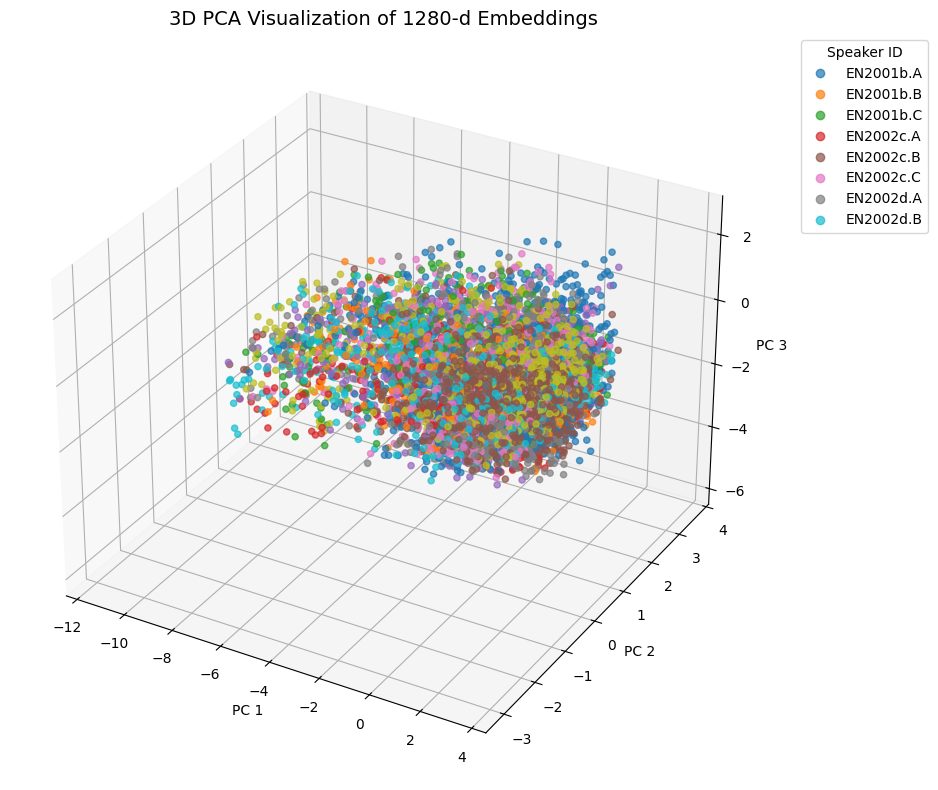

In [46]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=meta['speaker_label'], cmap='tab10', alpha=0.7)

ax.set_title("3D PCA Visualization of 1280-d Embeddings", fontsize=14)
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_zlabel("PC 3")

handles, labels = scatter.legend_elements()
legend_labels = sorted(label_map_df['speaker_id'].unique().tolist())
ax.legend(handles, legend_labels, title="Speaker ID", loc="upper left", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

# Base Classifier (WavLM + Whisper Baseline)
Fit a standard, linearly bounded machine learning baseline model to quantify the native separating information of the raw features.

In [47]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

baseline_clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42))
baseline_clf.fit(X[train_idx], y[train_idx])
y_pred_base = baseline_clf.predict(X[test_idx])
base_acc = accuracy_score(y[test_idx], y_pred_base)

print(f"WavLM+Whisper Base Accuracy: {base_acc * 100:.2f}%")

WavLM+Whisper Base Accuracy: 57.04%


# Temporal Transformer & Sequence Preparation
Formulate chronological sliding frame chunks into contextual, attention-ready sequence batches using PyTorch data utilities.

In [48]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class AudioSequenceDataset(Dataset):
    def __init__(self, features, labels, sequence_length=5):
        self.features = features
        self.labels = labels
        self.seq_len = sequence_length
        
    def __len__(self):
        return len(self.features) - self.seq_len + 1

    def __getitem__(self, idx):
        x_seq = self.features[idx : idx + self.seq_len]
        y_label = self.labels[idx + self.seq_len - 1]
        return torch.tensor(x_seq, dtype=torch.float32), torch.tensor(y_label, dtype=torch.long)

SEQUENCE_LENGTH = 5

train_dataset = AudioSequenceDataset(X[train_idx], y[train_idx], sequence_length=SEQUENCE_LENGTH)
val_dataset   = AudioSequenceDataset(X[val_idx], y[val_idx], sequence_length=SEQUENCE_LENGTH)
test_dataset  = AudioSequenceDataset(X[test_idx], y[test_idx], sequence_length=SEQUENCE_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}")

Train samples: 4205 | Test samples: 1267


# Neural Sequence Architecture & Training
Instantiate a non-pretrained custom Transformer Encoder module to compute temporal contextual relationships and map voice transitions over the timeline axis.

In [49]:
import torch.nn as nn

class SpeakerTransformerRefiner(nn.Module):
    def __init__(self, input_dim=1280, num_train_classes=num_classes, d_model=256, nhead=4, num_layers=2, dim_feedforward=512, dropout=0.3):
        super(SpeakerTransformerRefiner, self).__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, num_train_classes)
        
    def forward(self, x, extract_embeddings=False):
        x = self.input_proj(x)
        x = self.transformer(x)
        pooled_embeddings = x.mean(dim=1)
        if extract_embeddings:
            return pooled_embeddings
        return self.fc(pooled_embeddings)

model = SpeakerTransformerRefiner(num_train_classes=num_classes).to(device)

In [50]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
epochs = 30

plot_train_acc = []
plot_val_acc = []

print("Training Transformer optimization nodes...")
for epoch in range(epochs):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x, extract_embeddings=False)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch_x.size(0)
        _, predicted = torch.max(outputs, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == batch_y).sum().item()
        
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x, extract_embeddings=False)
            _, predicted = torch.max(outputs, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == batch_y).sum().item()
            
    t_acc = (train_correct / train_total) * 100
    v_acc = (val_correct / val_total) * 100 if val_total > 0 else 0.0
    plot_train_acc.append(t_acc)
    plot_val_acc.append(v_acc)
    print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {train_loss/train_total:.4f} | Train Acc: {t_acc:.2f}% | Val Acc: {v_acc:.2f}%")

Training Transformer optimization nodes...
Epoch 01/30 | Loss: 4.1794 | Train Acc: 13.46% | Val Acc: 21.68%
Epoch 02/30 | Loss: 2.0733 | Train Acc: 47.56% | Val Acc: 26.45%
Epoch 03/30 | Loss: 1.3463 | Train Acc: 60.14% | Val Acc: 36.83%
Epoch 04/30 | Loss: 1.0689 | Train Acc: 65.54% | Val Acc: 34.34%
Epoch 05/30 | Loss: 0.9181 | Train Acc: 69.44% | Val Acc: 35.68%
Epoch 06/30 | Loss: 0.8382 | Train Acc: 71.34% | Val Acc: 31.54%
Epoch 07/30 | Loss: 0.7641 | Train Acc: 73.20% | Val Acc: 31.64%
Epoch 08/30 | Loss: 0.7127 | Train Acc: 74.72% | Val Acc: 34.13%
Epoch 09/30 | Loss: 0.6651 | Train Acc: 76.27% | Val Acc: 37.24%
Epoch 10/30 | Loss: 0.6205 | Train Acc: 77.62% | Val Acc: 31.33%
Epoch 11/30 | Loss: 0.5856 | Train Acc: 78.91% | Val Acc: 35.17%
Epoch 12/30 | Loss: 0.5628 | Train Acc: 78.79% | Val Acc: 35.06%
Epoch 13/30 | Loss: 0.5532 | Train Acc: 79.67% | Val Acc: 36.10%
Epoch 14/30 | Loss: 0.5277 | Train Acc: 80.55% | Val Acc: 36.72%
Epoch 15/30 | Loss: 0.5014 | Train Acc: 81.38% 

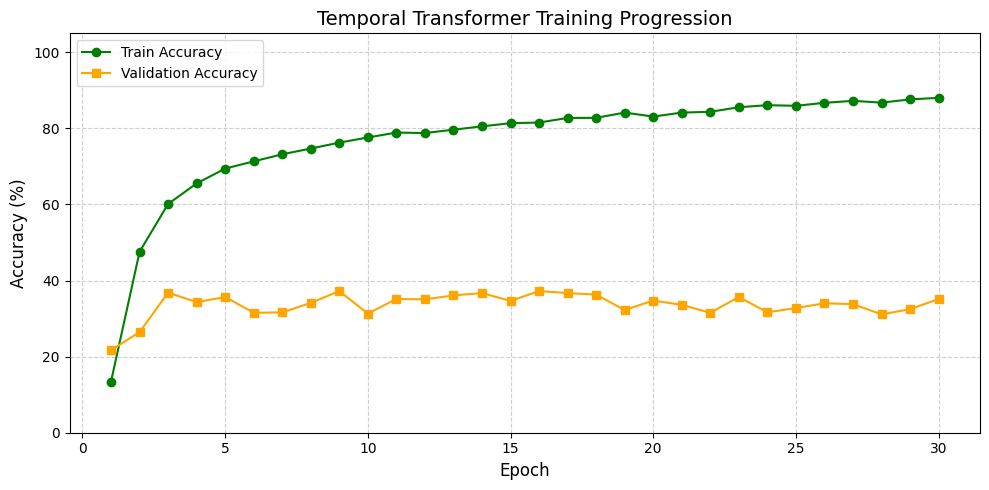

         SPEAKER DIARIZATION EVALUATION        
Final Train Accuracy (Supervised): 88.04%
Final Val Accuracy (Supervised):   35.17%


In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(plot_train_acc) + 1), plot_train_acc, label='Train Accuracy', color='green', marker='o')
plt.plot(range(1, len(plot_val_acc) + 1), plot_val_acc, label='Validation Accuracy', color='orange', marker='s')
plt.title('Temporal Transformer Training Progression', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

print("=" * 45)
print("         SPEAKER DIARIZATION EVALUATION        ")
print("=" * 45)
print(f"Final Train Accuracy (Supervised): {plot_train_acc[-1]:.2f}%")
print(f"Final Val Accuracy (Supervised):   {plot_val_acc[-1]:.2f}%")
print("=" * 45)

# Unsupervised Open-Set Speaker Diarization (Per-Meeting)
Bypass the static classification layer and execute adaptive, localized K-Means clustering independently per meeting file to evaluate speaker segmentation performance on unseen individuals.

In [52]:
import numpy as np
import torch
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

print("Extracting both Supervised and Unsupervised streams for testing...")
model.eval()

extracted_embeddings = []
supervised_class_predictions = []
ground_truth_labels = []

# 1. Loop over test data and pull predictions from BOTH layers of your Transformer
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        
        # Stream A: Unsupervised Encodings (For K-Means)
        embeddings = model(batch_x, extract_embeddings=True)
        extracted_embeddings.append(embeddings.cpu().numpy())
        
        # Stream B: Supervised Logits (Direct Classifier Head Guess)
        supervised_logits = model(batch_x, extract_embeddings=False)
        supervised_preds = torch.argmax(supervised_logits, dim=1)
        supervised_class_predictions.append(supervised_preds.cpu().numpy())
        
        ground_truth_labels.append(batch_y.numpy())

# Flatten list streams into clean numpy arrays
extracted_embeddings = np.concatenate(extracted_embeddings, axis=0)
supervised_class_predictions = np.concatenate(supervised_class_predictions, axis=0)
ground_truth_labels = np.concatenate(ground_truth_labels, axis=0)

# 2. Perform the Per-Meeting Unsupervised K-Means loop
test_meta = meta.iloc[test_idx].iloc[SEQUENCE_LENGTH - 1 :].reset_index(drop=True)
unique_meetings = test_meta['meeting'].unique()
per_meeting_cluster_assignments = np.zeros(len(extracted_embeddings), dtype=int)

all_meeting_aris = []
all_meeting_silhouettes = []

for meeting in unique_meetings:
    meeting_mask = (test_meta['meeting'] == meeting).values
    meeting_embeddings = extracted_embeddings[meeting_mask]
    meeting_truth = ground_truth_labels[meeting_mask]
    
    k_local = len(np.unique(meeting_truth))
    if k_local < 2: continue
    
    kmeans = KMeans(n_clusters=k_local, random_state=42, n_init=10)
    local_preds = kmeans.fit_predict(meeting_embeddings)
    per_meeting_cluster_assignments[meeting_mask] = local_preds
    
    meeting_ari = adjusted_rand_score(meeting_truth, local_preds)
    all_meeting_aris.append(meeting_ari)
    if len(meeting_embeddings) > k_local:
        all_meeting_silhouettes.append(silhouette_score(meeting_embeddings, local_preds))

print("=" * 50)
print("         PER-MEETING OPEN-SET DIARIZATION          ")
print("=" * 50)
print(f"Average Per-Meeting ARI Score:        {np.mean(all_meeting_aris):.4f}")
print(f"Average Per-Meeting Silhouette Score: {np.mean(all_meeting_silhouettes):.4f}")
print("=" * 50)

Extracting both Supervised and Unsupervised streams for testing...
         PER-MEETING OPEN-SET DIARIZATION          
Average Per-Meeting ARI Score:        0.1962
Average Per-Meeting Silhouette Score: 0.3134


# Geometric Latent Space Visualizations
Render 2D side-by-side scatter plots using Principal Component Analysis along with a performance comparison bar chart.

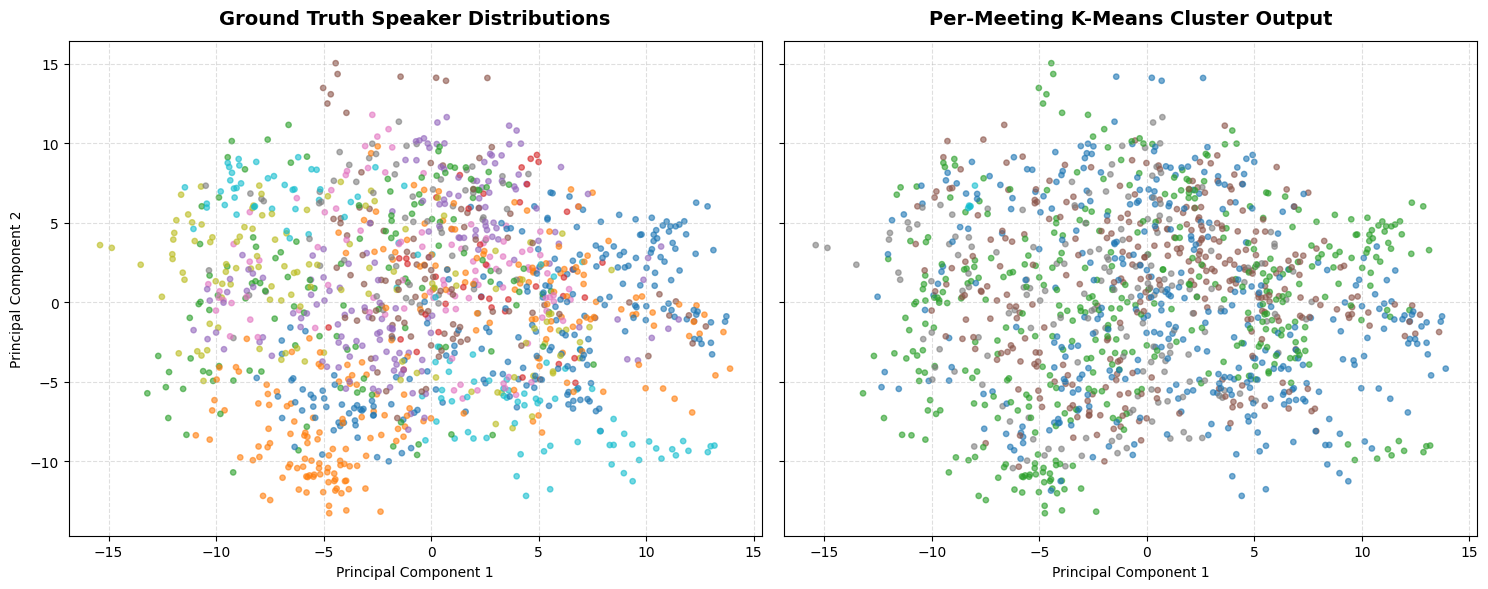

In [53]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(extracted_embeddings)

max_plot_points = min(3000, len(embeddings_2d))
np.random.seed(42)
random_indices = np.random.choice(len(embeddings_2d), max_plot_points, replace=False)

X_plot = embeddings_2d[random_indices]
labels_true = ground_truth_labels[random_indices]
labels_pred = per_meeting_cluster_assignments[random_indices]

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
cmap_choice = 'tab10'

axes[0].scatter(X_plot[:, 0], X_plot[:, 1], c=labels_true, cmap=cmap_choice, alpha=0.6, s=15)
axes[0].set_title("Ground Truth Speaker Distributions", fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].scatter(X_plot[:, 0], X_plot[:, 1], c=labels_pred, cmap=cmap_choice, alpha=0.6, s=15)
axes[1].set_title("Per-Meeting K-Means Cluster Output", fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel("Principal Component 1")
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Automated Transcription Timeline Generation
Initialize a CTranslate2 optimized `faster-whisper` model engine to generate speech transcripts and compile conversational audio blocks into speaker-attributed timelines.

In [54]:
import torch
from faster_whisper import WhisperModel

whisper_device = "cuda" if torch.cuda.is_available() else "cpu"
WHISPER_MODEL_SIZE = "small"
compute_type = "float16" if whisper_device == "cuda" else "int8"

print(f"Target hardware configuration: {whisper_device}")
print(f"Compiling Faster-Whisper layers: {WHISPER_MODEL_SIZE}")

whisper_model = WhisperModel(
    WHISPER_MODEL_SIZE,
    device=whisper_device,
    compute_type=compute_type
)
print("Faster-Whisper core engine loaded successfully.")

Target hardware configuration: cuda
Compiling Faster-Whisper layers: small
Faster-Whisper core engine loaded successfully.


In [55]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.metrics import accuracy_score, adjusted_rand_score

# 1. Build identity map matrices
label_to_speaker_id = dict(zip(label_map_df["speaker_label"], label_map_df["speaker_id"]))

# 2. Extract and align target tracking vectors
speaker_timeline_transcription = test_meta.copy()
speaker_timeline_transcription["true_speaker_label"] = ground_truth_labels
speaker_timeline_transcription["predicted_cluster_id"] = per_meeting_cluster_assignments
speaker_timeline_transcription["predicted_supervised_label"] = supervised_class_predictions

# 3. Format mapping strings
speaker_timeline_transcription["true_speaker_id"] = speaker_timeline_transcription["true_speaker_label"].map(label_to_speaker_id)
speaker_timeline_transcription["predicted_supervised_id"] = speaker_timeline_transcription["predicted_supervised_label"].map(label_to_speaker_id)
speaker_timeline_transcription["predicted_speaker_cluster"] = "Cluster_" + speaker_timeline_transcription["predicted_cluster_id"].astype(str)
speaker_timeline_transcription["predicted_supervised_id"] = speaker_timeline_transcription["predicted_supervised_id"].fillna("Unknown/Other")

# 4. Define text generation extraction parameters
def transcribe_audio_npy(audio_path, language="en"):
    audio_data = np.load(audio_path).astype(np.float32)
    segments, info = whisper_model.transcribe(audio_data, language=language, beam_size=5, vad_filter=True)
    text_blocks = [seg.text.strip() for seg in segments]
    return " ".join(text_blocks).strip()

print(f"Transcribing {len(speaker_timeline_transcription)} evaluation audio rows...")
compiled_transcripts = []

for path in tqdm(speaker_timeline_transcription["audio_path"], desc="Processing speech channels"):
    try:
        window_text = transcribe_audio_npy(path, language="en")
    except Exception as error_msg:
        window_text = f"[TRANSCRIPTION_FAILURE: {error_msg}]"
    compiled_transcripts.append(window_text)

speaker_timeline_transcription["transcript"] = compiled_transcripts

# 5. Compile side-by-side verification table
final_speaker_transcript = speaker_timeline_transcription[
    [
        "meeting",
        "start_time",
        "end_time",
        "true_speaker_id",
        "predicted_supervised_id",
        "predicted_speaker_cluster",
        "transcript"
    ]
].copy()

final_speaker_transcript = final_speaker_transcript.sort_values(["meeting", "start_time"]).reset_index(drop=True)

print("\n" + "="*100)
print("     FINAL DIARIZATION COMPARISON SCRIPT TIMELINE (UNSUPERVISED VS SUPERVISED)     ")
print("="*100)
display(final_speaker_transcript.head(30))

# 6. Compute metrics for immediate visualization printing
sup_acc = accuracy_score(ground_truth_labels, supervised_class_predictions) * 100
unsup_ari = adjusted_rand_score(ground_truth_labels, per_meeting_cluster_assignments)

print("\n" + "="*55)
print("         SPEAKER DIARIZATION EVALUATION SUMMARY        ")
print("="*55)
print(f"Final True Speaker Identification Accuracy (Supervised): {sup_acc:.2f}%")
print(f"Final Open-Set System Alignment Index  (Unsupervised): {unsup_ari:.4f}")
print("="*55)

# 7. Persist document matrix spreadsheet to directory path
transcript_output_path = SAVE_DIR / "final_speaker_diarization_transcription.csv"
final_speaker_transcript.to_csv(transcript_output_path, index=False)
print(f"\nSaved combined data table spreadsheet registry output to:\n--> {transcript_output_path}")

Transcribing 1267 evaluation audio rows...


Processing speech channels: 100%|██████████| 1267/1267 [24:12<00:00,  1.15s/it]


     FINAL DIARIZATION COMPARISON SCRIPT TIMELINE (UNSUPERVISED VS SUPERVISED)     


,meeting,start_time,end_time,true_speaker_id,predicted_supervised_id,predicted_speaker_cluster,transcript
0,EN2001b,960.0,990.0,EN2001b.B,EN2001b.B,Cluster_0,to be would be just if we have here a link to ...
1,EN2001b,975.0,1005.0,EN2001b.B,EN2001b.B,Cluster_0,"So you mean an attribute. Yeah. Yeah. Yeah, th..."
2,EN2001b,990.0,1020.0,EN2001b.B,EN2001b.B,Cluster_0,We won the reference and won just the number. ...
3,EN2001b,1005.0,1035.0,EN2001b.B,EN2001b.B,Cluster_0,which is there the value. So this whole inform...
4,EN2001b,1020.0,1050.0,EN2001b.B,EN2001b.B,Cluster_0,which attributes they bring in. So we would ad...
5,EN2001b,1035.0,1065.0,EN2001b.C,EN2001b.B,Cluster_0,"We couldn't call it segment, I'm not sure, we ..."
6,EN2001b,1050.0,1080.0,EN2001b.A,EN2001b.B,Cluster_0,"Yeah, I know that's probably not very nice, bu..."
7,EN2001b,1065.0,1095.0,EN2001b.A,EN2001b.B,Cluster_0,I think that is just the things that are loade...
8,EN2001b,1080.0,1110.0,EN2001b.A,EN2001b.A,Cluster_1,make our file one of those lazy loaded but I m...
9,EN2001b,1095.0,1125.0,EN2001b.A,EN2001b.B,Cluster_1,"you know, a basic thing that it loads, I think..."



         SPEAKER DIARIZATION EVALUATION SUMMARY        
Final True Speaker Identification Accuracy (Supervised): 31.73%
Final Open-Set System Alignment Index  (Unsupervised): 0.0199

Saved combined data table spreadsheet registry output to:
--> D:\ANN\ANN_Project\working\outputs\saved\final_speaker_diarization_transcription.csv


# Word Error Rate (WER) and Character Error Rate (CER)

In [56]:
print("Available meetings in your test split:")
print(final_speaker_transcript['meeting'].unique())

Available meetings in your test split:
<StringArray>
['EN2001b', 'EN2002d', 'EN2003a', 'EN2005a', 'EN2006a', 'ES2003c', 'ES2003d',
 'ES2004a', 'ES2004c', 'ES2006d', 'ES2007b', 'ES2007d', 'ES2008a', 'ES2010a',
 'ES2012b', 'ES2012d', 'ES2014d', 'ES2015c', 'ES2015d',  'IN1007',  'IN1008',
  'IN1014', 'IS1003d', 'IS1004a', 'IS1005c', 'IS1009c', 'TS3005a', 'TS3006a',
 'TS3006c', 'TS3008a', 'TS3009a', 'TS3009b', 'TS3010a', 'TS3010d', 'TS3011a',
 'TS3012b']
Length: 36, dtype: str


In [64]:
import os
import glob
import xml.etree.ElementTree as ET
import pandas as pd
from pathlib import Path
from jiwer import wer, cer

# ========================================================
# CONFIGURATION: Change your meeting ID or paths here
# ========================================================
TARGET_MEETING = "EN2001b"
WORDS_DIR = r"D:\Dataset\ami_manual\words"

# Fallback cleanly to your verified MANUAL_PATH if directory doesn't exist standalone
if not os.path.exists(WORDS_DIR):
    WORDS_DIR = str(Path(MANUAL_PATH) / "words")

print(f"Evaluating machine transcription accuracy metrics for meeting: {TARGET_MEETING}")
print("=" * 75)

# 1. Locate and parse ground-truth word XML files
xml_pattern = os.path.join(WORDS_DIR, f"{TARGET_MEETING}.*.words.xml")
xml_files = glob.glob(xml_pattern)

# Safety check to verify prerequisites are in active session memory
if not xml_files:
    print(f"Error: No word token XML files found in {WORDS_DIR} matching meeting {TARGET_MEETING}")
elif 'final_speaker_transcript' not in locals() and 'final_speaker_transcript' not in globals():
    print("Error: Target final_speaker_transcript DataFrame structure not found in memory. Run your transcription loop first.")
else:
    # Isolate evaluation metrics specifically to the current target meeting selection
    df_target = final_speaker_transcript[final_speaker_transcript['meeting'] == TARGET_MEETING].copy()
    
    if df_target.empty:
        print(f"Warning: No transcribed window entries found for meeting {TARGET_MEETING} in your current final_speaker_transcript timeline array.")
    else:
        ground_truth_words = []
        
        # Extract every word token along with its specific timestamp bounds
        for f in xml_files:
            try:
                root = ET.parse(f).getroot()
                for w in root.findall('w'):
                    start = w.get('starttime')
                    end = w.get('endtime')
                    if start and end and w.text:
                        ground_truth_words.append({
                            'start': float(start),
                            'end': float(end),
                            'text': w.text.strip()
                        })
            except Exception:
                continue

        # Sort all extracted words chronologically
        ground_truth_words.sort(key=lambda x: x['start'])

        references = []
        hypotheses = []

        # 2. Align XML word timestamps with the sliding windows in your DataFrame
        for idx, row in df_target.iterrows():
            w_start = float(row['start_time'])
            w_end = float(row['end_time'])
            whisper_text = str(row['transcript']).strip().lower()

            # Collect ground truth words that fall inside this specific window timeline
            matched_words = [
                w['text'] for w in ground_truth_words
                if w['start'] >= w_start and w['end'] <= w_end
            ]
            
            gt_text = " ".join(matched_words).strip().lower()

            # Only evaluate if there is readable text in ground truth or prediction
            if gt_text or whisper_text:
                references.append(gt_text)
                hypotheses.append(whisper_text)

        # 3. Calculate and display linguistic accuracy evaluation metrics
        if references:
            error_rate_w = wer(references, hypotheses)
            error_rate_c = cer(references, hypotheses)
            accuracy = max(0.0, 1.0 - error_rate_w)

            print(f"Total Windows Evaluated   : {len(references)}")
            print(f"Word Error Rate (WER)     : {error_rate_w * 100:.2f}%")
            print(f"Character Error Rate (CER): {error_rate_c * 100:.2f}%")
            print(f"Linguistic Accuracy Matrix: {accuracy * 100:.2f}%")
            print("=" * 75)
            
            # Print a short text preview comparison for manual inspection
            print("Sample Comparison (First 2 active sliding window segments):")
            print("-" * 75)
            sample_count = 0
            for r, h in zip(references, hypotheses):
                if r.strip() and h.strip():
                    print(f"Ground Truth Transcript (XML Raw Token): {r}")
                    print(f"Faster-Whisper Prediction Output       : {h}")
                    print("-" * 75)
                    sample_count += 1
                    if sample_count >= 2:
                        break
        else:
            print("No overlapping chronological data timeline matches found to evaluate.")

Evaluating machine transcription accuracy metrics for meeting: EN2001b
Total Windows Evaluated   : 46
Word Error Rate (WER)     : 35.05%
Character Error Rate (CER): 17.47%
Linguistic Accuracy Matrix: 64.95%
Sample Comparison (First 2 active sliding window segments):
---------------------------------------------------------------------------
Ground Truth Transcript (XML Raw Token): to be would be just , if we have here a link to the segment , a like an i_d_ for that segment , that we just create another file which links to the segment and then has an additional value which is the number . so you mean an a an attribute yeah . yeah , yeah . . yeah , that's what i meant actually , yeah yeah , oh sorry , i . i thought we were talking about having two files . i was think yeah , i i think that i i understood wrong . i thought you were wanting to have two different x_m_l_
Faster-Whisper Prediction Output       : to be would be just if we have here a link to the segment, like an id for that seg

# Model Serialization and Deployment Assembly
Save model configurations, operational weight states, and structural maps to disk storage variables.

In [58]:
import joblib

_model_dir = SAVE_DIR / 'web_models'
_model_dir.mkdir(parents=True, exist_ok=True)

torch.save(model.state_dict(), _model_dir / 'temporal_transformer.pt')
torch.save(wavlm.state_dict(), _model_dir / 'wavlm_encoder.pt')
feature_extractor.save_pretrained(str(_model_dir / 'feature_extractor'))
joblib.dump(baseline_clf, _model_dir / 'baseline_clf.joblib')
label_map_df.to_csv(_model_dir / 'speaker_label_mapping.csv', index=False)

print(f"All artifacts successfully compiled and serialized inside: {_model_dir}")

All artifacts successfully compiled and serialized inside: D:\ANN\ANN_Project\working\outputs\saved\web_models
